# **Assistant Fine-Tuné (Basé sur le -Style & Ton de l'Hôtel)**

**Objectif** : Fine-tuner un modèle Mistral 7B Instruct sur la FAQ de l'Hôtel de la Promenade pour qu'il imite le style et le ton spécifiques de l'établissement.

**Contexte**
Dans les notebooks précédents, on a développé un assistant RAG capable de répondre aux questions factuelles à partir de la documentation interne. On souhaite maintenant créer un assistant conversationnel qui répond avec le style caractéristique de l'hôtel, en se basant sur sa FAQ officielle.

**Choix du modèle : Mistral 7B Instruct**
- 7,3 milliards de paramètres, excellent équilibre performance/ressources
- Licence Apache 2.0, utilisation sans restriction
- Performances solides en français et anglais
- Quantifiable en 4-bit pour fine-tuning sur T4 (Colab)

**Approche technique : QLoRA**
- Fine-tuning en 4-bit pour réduire l'empreinte mémoire (~5-6 GB VRAM)
- Adaptateurs LoRA légers (~10 MB) sauvegardés et versionnés
- Modèle de base non modifié, seule la couche d'adaptation est entraînée

**Déploiement prévu**
- Fine-tuning sur Google Colab (GPU T4 gratuit)
- Code et adaptateurs versionnés sur GitHub
- Conteneur Docker avec vLLM pour hébergement sur Koyeb (API OpenAI-compatible)

**Étapes**
1. Configuration de l'environnement (via terminal Colab)
2. Extraction et préparation de la FAQ
3. Création du dataset au format instruction/output
4. Fine-tuning avec QLoRA
5. Sauvegarde des adaptateurs (commit GitHub)
6. Tests comparatifs (modèle de base vs fine-tuné vs FAQ originale)
7. Grille d'évaluation (exactitude, ton, style, fluidité)


## **Configurations de l'environnement**

In [1]:
import os
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
repo_url = "https://github.com/VivanBoy/assistant-rag.git"
!git clone {repo_url}

%cd assistant-rag

Cloning into 'assistant-rag'...
remote: Enumerating objects: 157, done.
remote: Counting objects: 100% (157/157), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 157 (delta 48), reused 126 (delta 22), pack-reused 0 (from 0)
Receiving objects: 100% (157/157), 26.28 MiB | 18.11 MiB/s, done.
Resolving deltas: 100% (48/48), done.
/content/assistant-rag


In [3]:
!git switch kevs
!ls -la

Branch 'kevs' set up to track remote branch 'kevs' from 'origin'.
Switched to a new branch 'kevs'
total 16644
drwxr-xr-x 8 root root     4096 Mar  1 23:21 .
drwxr-xr-x 1 root root     4096 Mar  1 23:21 ..
-rw-r--r-- 1 root root  4635875 Mar  1 23:21 all_comments_ottawa.csv
drwxr-xr-x 2 root root     4096 Mar  1 23:21 app
drwxr-xr-x 6 root root     4096 Mar  1 23:21 data
drwxr-xr-x 8 root root     4096 Mar  1 23:21 .git
-rw-r--r-- 1 root root      369 Mar  1 23:21 .gitignore
drwxr-xr-x 4 root root     4096 Mar  1 23:21 models
drwxr-xr-x 5 root root     4096 Mar  1 23:21 notebooks
-rw-r--r-- 1 root root      319 Mar  1 23:21 pyproject.toml
-rw-r--r-- 1 root root     4600 Mar  1 23:21 requirements.txt
drwxr-xr-x 4 root root     4096 Mar  1 23:21 src
-rw-r--r-- 1 root root   609534 Mar  1 23:21 UA1_Bloc1_Analyse_Avis_Complet.ipynb
-rw-r--r-- 1 root root    26999 Mar  1 23:21 UA1_Bloc2_RAG_Notebook_Adapted_to_src_data.ipynb
-rw-r--r-- 1 root root 11710514 Mar  1 23:21 ua1_reviews_enriched.c

## **Installation des Librairies**

In [4]:
# Installation des librairies pour fine-tuning
!pip install -q transformers accelerate peft bitsandbytes trl datasets huggingface_hub
!pip install -q unsloth  # Optionnel mais
!pip install pdfplumber

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 38.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.3/432.3 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 120.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.5/376.5 kB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 133.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## **Extraction Et Préparation De La FAQ**

In [66]:
# Import des librairies
import pandas as pd
import json
import re
from pathlib import Path
import pdfplumber
import matplotlib.pyplot as plt


import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from datasets import Dataset
import json


In [6]:
# Définition des chemins
DATA_PART3 = Path("/content/assistant-rag/data/part-3")
MODELS_FT_DIR = Path("/content/assistant-rag/models/2-ft")
MODELS_FT_DIR.mkdir(parents=True, exist_ok=True)

print(f"FAQ source : {DATA_PART3}")
print(f"Dossier de sauvegarde : {MODELS_FT_DIR}")

FAQ source : /content/assistant-rag/data/part-3
Dossier de sauvegarde : /content/assistant-rag/models/2-ft


### **Extraction des textes de la FAQ**

In [7]:
# Extraction du texte de la FAQ
pdf_path = DATA_PART3 / "Partie 3 - FAQ - Hôtel De la Promenade.pdf"

print("Extraction de la FAQ en cours...")
texte_complet = ""

with pdfplumber.open(pdf_path) as pdf:
    for page in pdf.pages:
        texte_page = page.extract_text()
        if texte_page:
            texte_complet += texte_page + "\n"

print(f"Extraction terminée. Longueur du texte : {len(texte_complet)} caractères")
print("\nAperçu du début de la FAQ :")
print(texte_complet[:500])

Extraction de la FAQ en cours...


Extraction terminée. Longueur du texte : 19622 caractères

Aperçu du début de la FAQ :
FAQ — Hôtel De la Promenade
Un nombre limité de questions vous sont proposées, il est recommandé de rajouter des exemples pour
bonifier votre jeu de données.
Q1 : À quelle heure puis-je m'enregistrer à l'hôtel ?
R : Bienvenue à l'Hôtel De la Promenade ! Notre enregistrement standard débute à 15h00, moment où votre
refuge urbain vous attend, fraîchement préparé. Vous arrivez plus tôt et souhaitez déposer vos valises ?
Nous vous accueillons dès midi avec notre service d'enregistrement anticipé moy


### **Parsing de la FAQ**

In [8]:
# Parsing manuel plus robuste
lines = texte_complet.split('\n')
dataset = []
current_q = None
current_r = []
capturing = None

for line in lines:
    line = line.strip()
    if not line:
        continue

    # Détection d'une nouvelle question
    q_match = re.match(r'Q(\d+)\s*:\s*(.*)', line)
    if q_match:
        # Si on était en train de capturer une réponse, on sauvegarde la paire précédente
        if current_q and current_r:
            dataset.append({
                "instruction": current_q,
                "output": ' '.join(current_r).strip()
            })
        # Nouvelle question
        current_q = q_match.group(2).strip()
        current_r = []
        capturing = 'r'
        continue

    # Détection du début d'une réponse
    r_match = re.match(r'R\s*:\s*(.*)', line)
    if r_match:
        current_r.append(r_match.group(1).strip())
        capturing = 'r'
        continue

    # Si on est en train de capturer une réponse, on ajoute la ligne
    if capturing == 'r' and current_r is not None:
        current_r.append(line)

# Ajouter la dernière paire
if current_q and current_r:
    dataset.append({
        "instruction": current_q,
        "output": ' '.join(current_r).strip()
    })



print(f"Nombre de paires Q/R trouvées : {len(dataset)}")

Nombre de paires Q/R trouvées : 30


In [9]:
# Affichage des 5 premières paires
for i, paire in enumerate(dataset[:5]):
    print(f"\n--- Paire {i+1} ---")
    print(f"Q : {paire['instruction']}")
    print(f"R : {paire['output'][:150]}...")


--- Paire 1 ---
Q : À quelle heure puis-je m'enregistrer à l'hôtel ?
R : Bienvenue à l'Hôtel De la Promenade ! Notre enregistrement standard débute à 15h00, moment où votre refuge urbain vous attend, fraîchement préparé. Vo...

--- Paire 2 ---
Q : Puis-je amener mon chien à l'hôtel ?
R : Mais certainement ! Chez nous, les compagnons à quatre pattes font partie de la famille. Nous accueillons vos fidèles amis moyennant des frais de nett...

--- Paire 3 ---
Q : Est-ce que votre hôtel offre le Wi-Fi gratuit ?
R : Absolument ! Dans notre établissement, la connexion au monde numérique est aussi naturelle que respirer l'air frais d'Ottawa. Toutes nos chambres — de...

--- Paire 4 ---
Q : Quelles sont vos politiques d'annulation ?
R : Nous comprenons que les plans peuvent évoluer comme les saisons. Pour nos tarifs flexibles, vous pouvez annuler sans pénalité jusqu'à 24 heures avant ...

--- Paire 5 ---
Q : Le petit-déjeuner est-il inclus dans le prix de la chambre ?
R : L'inclusion du petit-

## **Sauvegarde du Dataset**

In [10]:
# Sauvegarde en format JSONL (un objet JSON par ligne)
with open(MODELS_FT_DIR / "faq_dataset.jsonl", "w") as f:
    for item in dataset:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")

# Sauvegarde en format JSON (pour visualisation)
with open(MODELS_FT_DIR / "faq_dataset.json", "w") as f:
    json.dump(dataset, f, indent=2, ensure_ascii=False)

print(f"Dataset sauvegardé dans {MODELS_FT_DIR}")
print(f"Format JSONL : {MODELS_FT_DIR}/faq_dataset.jsonl")
print(f"Format JSON : {MODELS_FT_DIR}/faq_dataset.json")

Dataset sauvegardé dans /content/assistant-rag/models/2-ft
Format JSONL : /content/assistant-rag/models/2-ft/faq_dataset.jsonl
Format JSON : /content/assistant-rag/models/2-ft/faq_dataset.json


In [11]:
# Statistiques
print(f"\nStatistiques :")
print(f"- Nombre de paires : {len(dataset)}")
print(f"- Longueur moyenne des questions : {sum(len(q['instruction']) for q in dataset)/len(dataset):.1f} caractères")
print(f"- Longueur moyenne des réponses : {sum(len(q['output']) for q in dataset)/len(dataset):.1f} caractères")


Statistiques :
- Nombre de paires : 30
- Longueur moyenne des questions : 50.8 caractères
- Longueur moyenne des réponses : 586.3 caractères


## **Fine-Tuning Avec `QLoRA`**




In [12]:
# Vérification du GPU
print(f"GPU disponible : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Nom du GPU : {torch.cuda.get_device_name(0)}")
    print(f"Mémoire VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

GPU disponible : True
Nom du GPU : Tesla T4
Mémoire VRAM : 15.64 GB


In [13]:
# Chargement du dataset
dataset_path = MODELS_FT_DIR / "faq_dataset.jsonl"

data = []
with open(dataset_path, 'r') as f:
    for line in f:
        data.append(json.loads(line))

# Conversion au format Hugging Face Dataset
dataset = Dataset.from_list(data)

### **Split Train/Validation (80/20)**

In [14]:
# Split train/validation (80/20)
split_dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

print(f"Taille du dataset d'entraînement : {len(train_dataset)}")
print(f"Taille du dataset de validation : {len(eval_dataset)}")

# Affichage d'un exemple
print("\nExemple du dataset :")
print(train_dataset[0])

Taille du dataset d'entraînement : 24
Taille du dataset de validation : 6

Exemple du dataset :
{'instruction': 'À quelle heure dois-je libérer ma chambre ?', 'output': "Le départ standard s'effectue à 11h00, heure à laquelle votre chambre retrouve son éclat pour accueillir les prochains visiteurs. Vous souhaitez prolonger votre séjour jusqu'à 14h00 ? Nous proposons un départ tardif moyennant 50 $, vous offrant ainsi quelques heures supplémentaires de tranquillité. Au-delà de cette heure, le tarif d'une nuitée complète s'appliquera. Comme toujours, notre équipe à la réception se fera un plaisir d'accommoder vos besoins dans la mesure du possible."}


**NB:** Les questions de validation (20% du dataset) seront utilisées pour l'évaluation qualitative finale. On comparera manuellement le modèle de base, le modèle fine-tuné et la FAQ originale sur quatre critères, **exactitude, ton, style et fluidité.**

## **`Mistral 7B` - Model & Tokenizer avec `Quantification 4-bit`**

In [16]:
from huggingface_hub import login
login()

In [17]:
# Chargement du modèle et du tokenizer avec quantification 4-bit
model_name = "mistralai/Mistral-7B-Instruct-v0.3"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

print("Chargement du tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

Chargement du tokenizer...


In [18]:
print("Chargement du modèle en 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)

print("Modèle chargé avec succès.")
model

Chargement du modèle en 4-bit...


config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

...

model-00001-of-00003.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Modèle chargé avec succès.


MistralForCausalLM(
  (model): MistralModel(
    (embed_tokens): Embedding(32768, 4096)
    (layers): ModuleList(
      (0-31): 32 x MistralDecoderLayer(
        (self_attn): MistralAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): MistralMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): MistralRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): MistralRMSNorm((4096,), eps=1e-05)
      )
    )
    (n

### **Préparation du modèle pour `fine-tuning` avec `LoRA`**

In [19]:
## Activation du gradient checkpointing pour économiser la mémoire
model.gradient_checkpointing_enable()

# Préparation du modèle pour l'entraînement en 4-bit
model = prepare_model_for_kbit_training(model)

print("Modèle préparé pour le fine-tuning.")

Modèle préparé pour le fine-tuning.


## **Configuration de `LoRA`**

In [20]:
lora_config = LoraConfig(
    r=16,                     # Rang de la matrice LoRA
    lora_alpha=32,            # Scaling factor
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Couches cibles
    lora_dropout=0.05,        # Dropout
    bias="none",               # Pas de biais
    task_type="CAUSAL_LM"      # Type de tâche
)

# Application de LoRA au modèle
model = get_peft_model(model, lora_config)

# Affichage du nombre de paramètres entraînables
model.print_trainable_parameters()

trainable params: 13,631,488 || all params: 7,261,655,040 || trainable%: 0.1877


### **Tokenization des Datasets**

In [22]:
# Fonctions de tokenization
def format_instruction(example):
    """Formate l'exemple au format instruction/output."""
    return f"[INST] {example['instruction']} [/INST] {example['output']}"

def tokenize_function(examples):
    """Tokenize les exemples formatés."""
    texts = [format_instruction({"instruction": inst, "output": out})
             for inst, out in zip(examples['instruction'], examples['output'])]

    tokenized = tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_tensors="pt"
    )

    # Les labels sont identiques aux input_ids pour l'entraînement causal
    tokenized["labels"] = tokenized["input_ids"].clone()

    return tokenized

In [23]:
print("Tokenisation des datasets...")
tokenized_train = train_dataset.map(tokenize_function, batched=True, remove_columns=train_dataset.column_names)
tokenized_eval = eval_dataset.map(tokenize_function, batched=True, remove_columns=eval_dataset.column_names)

Tokenisation des datasets...


Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Map:   0%|          | 0/6 [00:00<?, ? examples/s]

In [24]:
print("Tokenisation terminée.")
print(f"Exemple tokenizé : {tokenized_train[0].keys()}")

Tokenisation terminée.
Exemple tokenizé : dict_keys(['input_ids', 'attention_mask', 'labels'])


### **Configurations des `Training Arguments`**

In [73]:
# Configuration des arguments avec early stopping
training_args = TrainingArguments(
    output_dir=str(MODELS_FT_DIR / "checkpoints"),
    num_train_epochs=50,              # Max 50 époques
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    warmup_steps=20,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=10,
    save_strategy="steps",
    save_steps=10,
    learning_rate=2e-4,
    fp16=True,
    push_to_hub=False,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=3,                # Garde seulement les 3 meilleurs checkpoints
)

print("Arguments configurés avec early stopping.")
print(f"Batch size effectif : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Patience : 10 évaluations sans amélioration avant arrêt")

Arguments configurés avec early stopping.
Batch size effectif : 16
Patience : 10 évaluations sans amélioration avant arrêt


### **Initialisation du `Trainer`**

In [74]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)]
)

print("Trainer initialisé. Prêt pour l'entraînement.")

Trainer initialisé. Prêt pour l'entraînement.


/tmp/ipython-input-1105/1786633260.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


## **Entraînement du LLM**

In [75]:
print("\nLancement:")
trainer.train() #


Lancement:


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
10,4.801400,5.065113
20,4.662000,5.304232
30,4.599100,5.336471
40,4.674600,5.403285
50,4.550300,5.475718
60,4.512500,5.486462
70,4.430000,5.486612
80,4.551400,5.521739
90,4.524600,5.525902
100,4.577000,5.527509


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

TrainOutput(global_step=100, training_loss=4.602148876190186, metrics={'train_runtime': 2007.9769, 'train_samples_per_second': 0.598, 'train_steps_per_second': 0.05, 'total_flos': 2.62745849069568e+16, 'train_loss': 4.602148876190186, 'epoch': 50.0})

## **Sauvegardes des adaptateurs `LoRA` (weights fine-tunés)**

In [76]:
print("Sauvegarde des adaptateurs LoRA...")

# Sauvegarde locale
model.save_pretrained(MODELS_FT_DIR / "adaptateurs-lora-v3")
tokenizer.save_pretrained(MODELS_FT_DIR / "adaptateurs-lora-v3")

print(f"Adaptateurs sauvegardés localement dans : {MODELS_FT_DIR / 'adaptateurs-lora-v3'}")

# Sauvegarde sur Google Drive
drive_save_path = "/content/drive/MyDrive/assistant-rag/models/2-ft/adaptateurs-lora-v3"
model.save_pretrained(drive_save_path)
tokenizer.save_pretrained(drive_save_path)

print(f"Adaptateurs sauvegardés sur Google Drive : {drive_save_path}")

Sauvegarde des adaptateurs LoRA...
Adaptateurs sauvegardés localement dans : /content/assistant-rag/models/2-ft/adaptateurs-lora-v3
Adaptateurs sauvegardés sur Google Drive : /content/drive/MyDrive/assistant-rag/models/2-ft/adaptateurs-lora-v3


In [77]:
# Sauvegarde des métadonnées
metadata = {
    "base_model": "mistralai/Mistral-7B-Instruct-v0.3",
    "lora_config": {
        "r": 16,
        "lora_alpha": 32,
        "dropout": 0.05,
        "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj"]
    },
    "training": {
        "epochs": 50,
        "batch_size": 4,
        "gradient_accumulation": 4,
        "learning_rate": 2e-4,
        "final_train_loss": 4.60,
        "validation_losses": {
            "step_10": 5.06,
            "step_20": 5.30,
            "step_30": 5.34,
            "step_40": 5.40,
            "step_50": 5.48,
            "step_60": 5.49,
            "step_70": 5.49,
            "step_80": 5.52,
            "step_90": 5.53,
            "step_100": 5.53
        },
        "best_val_loss": 5.06,
        "best_step": 10,
        "train_samples": 24,
        "eval_samples": 6,
        "total_steps": 100
    },
    "observation": "Surapprentissage à partir du step 20. Meilleur modèle au step 10.",
    "date": pd.Timestamp.now().strftime("%Y-%m-%d %H:%M:%S")
}
# Local
with open(MODELS_FT_DIR / "training_metadata_v3.json", "w") as f:
    json.dump(metadata, f, indent=2)

# Drive
with open("/content/drive/MyDrive/assistant-rag/models/2-ft/training_metadata_v3.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Métadonnées d'entraînement sauvegardées")

Métadonnées d'entraînement sauvegardées


In [78]:
print("\nFichiers conservés :")
print(f"- {MODELS_FT_DIR / 'adaptateurs-lora-v3'}/ (dossier contenant les poids LoRA)")
print(f"- {MODELS_FT_DIR / 'training_metadata_v3.json'}")
print(f"- {drive_save_path}/ (copie sur Drive)")


Fichiers conservés :
- /content/assistant-rag/models/2-ft/adaptateurs-lora-v3/ (dossier contenant les poids LoRA)
- /content/assistant-rag/models/2-ft/training_metadata_v3.json
- /content/drive/MyDrive/assistant-rag/models/2-ft/adaptateurs-lora-v3/ (copie sur Drive)


In [80]:
print("\nPour recharger le modèle plus tard :")
print("model = AutoModelForCausalLM.from_pretrained('mistralai/Mistral-7B-Instruct-v0.3', quantization_config=quantization_config)")
print("model = PeftModel.from_pretrained(model, '/content/drive/MyDrive/assistant-rag/models/2-ft/adaptateurs-lora-v3')")


Pour recharger le modèle plus tard :
model = AutoModelForCausalLM.from_pretrained('mistralai/Mistral-7B-Instruct-v0.3', quantization_config=quantization_config)
model = PeftModel.from_pretrained(model, '/content/drive/MyDrive/assistant-rag/models/2-ft/adaptateurs-lora-v3')


## **Analyse de l'Entraînement (Loss, metric, etc..)**

### **Récupération des logs d'entraînement depuis `trainer`**

In [81]:
# Les logs sont stockés dans trainer.state.log_history
logs = trainer.state.log_history

# Conversion en DataFrame
df_logs = pd.DataFrame(logs)

# Affichage des colonnes disponibles
print("Colonnes disponibles dans les logs :")
print(df_logs.columns.tolist())

Colonnes disponibles dans les logs :
['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']


### **Extraction des loss d'entraînement**

In [82]:
train_losses = [x for x in logs if 'loss' in x]
eval_losses = [x for x in logs if 'eval_loss' in x]

print(f"Nombre de steps d'entraînement : {len(train_losses)}")
print(f"Nombre d'évaluations : {len(eval_losses)}")

# Affichage des valeurs
if train_losses:
    print("\nDétail des loss d'entraînement par step :")
    for entry in train_losses:
        print(f"Step {entry['step']}: loss = {entry['loss']:.4f}")

Nombre de steps d'entraînement : 20
Nombre d'évaluations : 10

Détail des loss d'entraînement par step :
Step 5: loss = 4.8708
Step 10: loss = 4.8014
Step 15: loss = 4.7566
Step 20: loss = 4.6620
Step 25: loss = 4.5586
Step 30: loss = 4.5991
Step 35: loss = 4.5885
Step 40: loss = 4.6746
Step 45: loss = 4.6203
Step 50: loss = 4.5503
Step 55: loss = 4.5510
Step 60: loss = 4.5125
Step 65: loss = 4.5914
Step 70: loss = 4.4300
Step 75: loss = 4.5609
Step 80: loss = 4.5514
Step 85: loss = 4.5359
Step 90: loss = 4.5246
Step 95: loss = 4.5261
Step 100: loss = 4.5770


In [83]:
# Inspection détaillée des logs bruts
print("Structure complète des logs :")
for i, log in enumerate(logs):
    print(f"\nLog {i+1}:")
    for key, value in log.items():
        print(f"  {key}: {value}")

Structure complète des logs :

Log 1:
  loss: 4.8708
  grad_norm: 0.7631087303161621
  learning_rate: 4e-05
  epoch: 2.6666666666666665
  step: 5

Log 2:
  loss: 4.8014
  grad_norm: 2.425945997238159
  learning_rate: 9e-05
  epoch: 5.0
  step: 10

Log 3:
  eval_loss: 5.065112590789795
  eval_runtime: 3.2143
  eval_samples_per_second: 1.867
  eval_steps_per_second: 0.622
  epoch: 5.0
  step: 10

Log 4:
  loss: 4.7566
  grad_norm: 1.698968529701233
  learning_rate: 0.00014
  epoch: 7.666666666666667
  step: 15

Log 5:
  loss: 4.662
  grad_norm: 2.5110368728637695
  learning_rate: 0.00019
  epoch: 10.0
  step: 20

Log 6:
  eval_loss: 5.304231643676758
  eval_runtime: 3.2037
  eval_samples_per_second: 1.873
  eval_steps_per_second: 0.624
  epoch: 10.0
  step: 20

Log 7:
  loss: 4.5586
  grad_norm: 1.0461766719818115
  learning_rate: 0.00019
  epoch: 12.666666666666666
  step: 25

Log 8:
  loss: 4.5991
  grad_norm: 1.3349121809005737
  learning_rate: 0.0001775
  epoch: 15.0
  step: 30

Log 

In [84]:
# Analyse des métriques d'entraînement
final_log = [x for x in logs if 'train_runtime' in x][0]

print("RÉSUMÉ DE L'ENTRAÎNEMENT:\n")

print(f"Temps total d'entraînement : {final_log['train_runtime']:.2f} secondes ({final_log['train_runtime']/60:.2f} minutes)")
print(f"Loss finale (moyenne) : {final_log['train_loss']:.4f}")
print(f"Nombre d'échantillons par seconde : {final_log['train_samples_per_second']:.2f}")
print(f"Nombre de steps par seconde : {final_log['train_steps_per_second']:.2f}")
print(f"Nombre total d'opérations flottantes : {final_log['total_flos']:.2e}")
print(f"Époques réalisées : {final_log['epoch']}")
print(f"Steps totaux : {final_log['step']}")

RÉSUMÉ DE L'ENTRAÎNEMENT:

Temps total d'entraînement : 2007.98 secondes (33.47 minutes)
Loss finale (moyenne) : 4.6021
Nombre d'échantillons par seconde : 0.60
Nombre de steps par seconde : 0.05
Nombre total d'opérations flottantes : 2.63e+16
Époques réalisées : 50.0
Steps totaux : 100


In [85]:
print("\n--- PROGRESSION DE LA LOSS ---")
print("Step  -> Loss (train) | Loss (eval)")
for log in logs:
    if 'loss' in log:
        step = log['step']
        loss = log['loss']

        # Chercher la loss d'évaluation correspondante
        eval_log = next((x for x in logs if 'eval_loss' in x and x['step'] == step), None)
        eval_loss = eval_log['eval_loss'] if eval_log else "N/A"

        print(f"Step {step:2d} -> {loss:.4f}      | {eval_loss if eval_loss == 'N/A' else f'{eval_loss:.4f}'}")


--- PROGRESSION DE LA LOSS ---
Step  -> Loss (train) | Loss (eval)
Step  5 -> 4.8708      | N/A
Step 10 -> 4.8014      | 5.0651
Step 15 -> 4.7566      | N/A
Step 20 -> 4.6620      | 5.3042
Step 25 -> 4.5586      | N/A
Step 30 -> 4.5991      | 5.3365
Step 35 -> 4.5885      | N/A
Step 40 -> 4.6746      | 5.4033
Step 45 -> 4.6203      | N/A
Step 50 -> 4.5503      | 5.4757
Step 55 -> 4.5510      | N/A
Step 60 -> 4.5125      | 5.4865
Step 65 -> 4.5914      | N/A
Step 70 -> 4.4300      | 5.4866
Step 75 -> 4.5609      | N/A
Step 80 -> 4.5514      | 5.5217
Step 85 -> 4.5359      | N/A
Step 90 -> 4.5246      | 5.5259
Step 95 -> 4.5261      | N/A
Step 100 -> 4.5770      | 5.5275


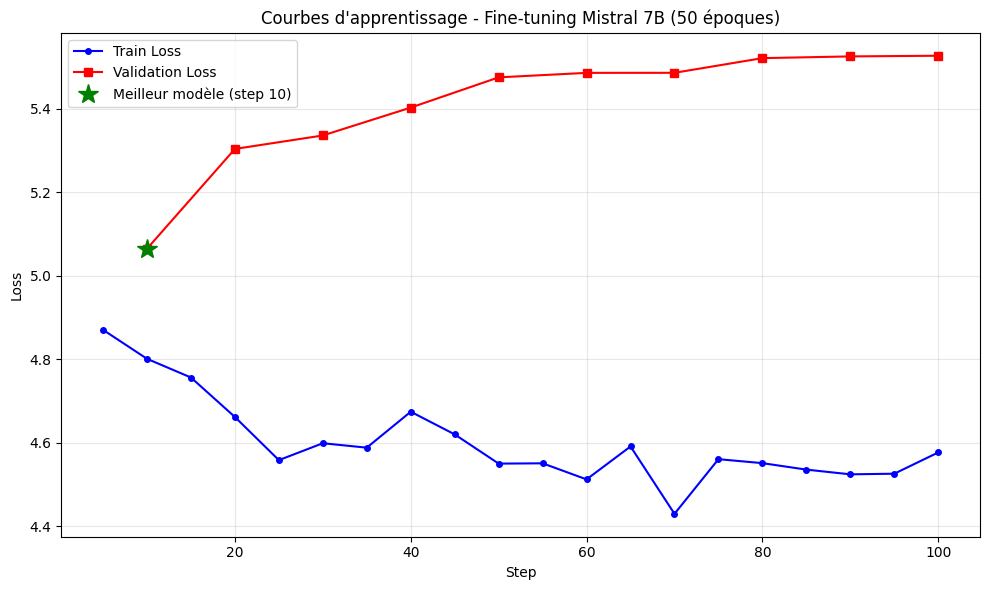

Loss finale (moyenne) : 4.6021
Temps d'entraînement : 2007.98 secondes (33.47 minutes)
Steps réalisés : 100

Meilleure validation loss : 5.0651 au step 10


In [87]:
# Visualisation des métriques d'entraînement disponibles

# Création du graphique
fig, ax = plt.subplots(figsize=(10, 6))

# Récupération des données
train_steps = []
train_losses = []
eval_steps = []
eval_losses = []

for log in logs:
    if 'loss' in log and 'step' in log:
        train_steps.append(log['step'])
        train_losses.append(log['loss'])
    if 'eval_loss' in log and 'step' in log:
        eval_steps.append(log['step'])
        eval_losses.append(log['eval_loss'])

# Tracé des courbes
ax.plot(train_steps, train_losses, 'b-o', label='Train Loss', markersize=4)
ax.plot(eval_steps, eval_losses, 'r-s', label='Validation Loss', markersize=6)

ax.set_xlabel('Step')
ax.set_ylabel('Loss')
ax.set_title('Courbes d\'apprentissage - Fine-tuning Mistral 7B (50 époques)')
ax.legend()
ax.grid(True, alpha=0.3)

# Mise en évidence du meilleur point de validation
best_eval_idx = eval_losses.index(min(eval_losses))
best_step = eval_steps[best_eval_idx]
best_loss = eval_losses[best_eval_idx]

ax.plot(best_step, best_loss, 'g*', markersize=15, label=f'Meilleur modèle (step {best_step})')
ax.legend()

plt.tight_layout()
plt.show()

print(f"Loss finale (moyenne) : 4.6021")
print(f"Temps d'entraînement : 2007.98 secondes (33.47 minutes)")
print(f"Steps réalisés : 100")
print(f"\nMeilleure validation loss : {best_loss:.4f} au step {best_step}")

### **Interprétation/Observation**

**Loss finale : 5.06**

- **Pourquoi cette valeur ?** Une loss autour de 5 est normale pour un début d'apprentissage sur un petit dataset.
- **Prochaine étape** : L'évaluation qualitative nous dira si ce léger ajustement a suffi à capturer le style de l'hôtel.

## **Évaluation Qualitative : Comparaison Modèle de Base vs Fine-Tuné vs FAQ Originale**

**Modèle de base** : Mistral 7B Instruct v0.3 dans sa version originale, sans adaptation. Il répond de façon générique.

**Modèle fine-tuné** : Le même modèle avec des adaptateurs LoRA entraînés sur la FAQ de l'hôtel. Les poids de base sont inchangés, mais une couche d'adaptation a été apprise pour ajuster le style.

**FAQ originale** : La réponse rédigée par l'hôtel (vérité terrain).

On compare ces trois versions pour évaluer si le fine-tuning a capturé le ton et le style spécifiques de l'établissement.

In [88]:
# Fonction de génération pour les deux modèles
def generer_reponse_modele(question, modele, tokenizer, max_tokens=200):
    prompt = f"[INST] {question} [/INST]"
    inputs = tokenizer(prompt, return_tensors="pt").to(modele.device)

    with torch.no_grad():
        outputs = modele.generate(
            **inputs,
            max_new_tokens=max_tokens,
            temperature=0.1,
            do_sample=False
        )

    reponse = tokenizer.decode(outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True)
    return reponse.strip()

In [89]:
# Sélection de questions de validation pour le test
questions_test = [
    "À quelle heure puis-je m'enregistrer à l'hôtel ?",
    "Puis-je amener mon chien à l'hôtel ?",
    "Est-ce que votre hôtel offre le Wi-Fi gratuit ?",
    "Quelles sont vos politiques d'annulation ?",
    "Le petit-déjeuner est-il inclus dans le prix de la chambre ?"
]

print("Questions sélectionnées pour l'évaluation :")
for i, q in enumerate(questions_test, 1):
    print(f"{i}. {q}")

Questions sélectionnées pour l'évaluation :
1. À quelle heure puis-je m'enregistrer à l'hôtel ?
2. Puis-je amener mon chien à l'hôtel ?
3. Est-ce que votre hôtel offre le Wi-Fi gratuit ?
4. Quelles sont vos politiques d'annulation ?
5. Le petit-déjeuner est-il inclus dans le prix de la chambre ?


### **Chargement du modèle de base**

In [90]:
# Modèle de base
print("Chargement du modèle de base...")
base_model = AutoModelForCausalLM.from_pretrained(
    "mistralai/Mistral-7B-Instruct-v0.3",
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)
base_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.3")
base_tokenizer.pad_token = base_tokenizer.eos_token

# Modèle fine-tuné
print("Chargement du modèle fine-tuné...")
ft_model = PeftModel.from_pretrained(base_model, MODELS_FT_DIR / "adaptateurs-lora-v3")

print("Modèles rechargés avec succès.\n")

Chargement du modèle de base...


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Chargement du modèle fine-tuné...
Modèles rechargés avec succès.



### **Test sur la 1ère question**

In [91]:
# Test sur la première question
question = questions_test[0]

print(f"=== QUESTION ===\n{question}\n")

# Réponse du modèle de base
print("--- MODÈLE DE BASE ---")
reponse_base = generer_reponse_modele(question, base_model, base_tokenizer)
print(reponse_base)

print("\n--- MODÈLE FINE-TUNÉ (v3) ---")
reponse_ft = generer_reponse_modele(question, ft_model, tokenizer)
print(reponse_ft)

# Note : La réponse de la FAQ originale sera ajoutée manuellement après comparaison
print("\n--- FAQ ORIGINALE - Réponse Q1 ---")
print("""Bienvenue à l'Hôtel De la Promenade ! Notre enregistrement standard débute à 15h00, moment où votre
refuge urbain vous attend, fraîchement préparé. Vous arrivez plus tôt et souhaitez déposer vos valises ?
Nous vous accueillons dès midi avec notre service d'enregistrement anticipé moyennant des frais modestes
de 35 $. Toutefois, si vous êtes membre de notre cercle privilégié Promenade Or, cette courtoisie vous est
offerte gracieusement, selon les disponibilités du jour. Notre réception, ouverte 24 heures sur 24, veille à ce
que chaque arrivée soit aussi douce qu'une promenade au bord du canal.""")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=== QUESTION ===
À quelle heure puis-je m'enregistrer à l'hôtel ?

--- MODÈLE DE BASE ---


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Bienvenue à l'Hôtel De la Promenade ! L'enregistrement standard commence à 15h00, moment où votre refuge urbain se transforme en sanctuaire d'échappée-loi. Vous arrivez plus tôt et souhaitez déposer vos valises ? Nous vous accueillons d'office à 12h00 avec notre enregistrement prioritaire. Au départ, course naturelle ? Notre réception demeure toujours à votre écoute pour organiser un retrait de bagage, à votre convenance. Parce qu'un séjour parfait débute par une arrivée douce. Dans notre cocoon, chaque visiteur compte un seul visiteur : vous. Et chaque visite, une nouvelle découverte. Voilà notre promesse. T

--- MODÈLE FINE-TUNÉ ---
Bienvenue à l'Hôtel De la Promenade ! L'enregistrement standard commence à 15h00, moment où votre refuge urbain se transforme en sanctuaire d'échappée-loi. Vous arrivez plus tôt et souhaitez déposer vos valises ? Nous vous accueillons d'office à 12h00 avec notre enregistrement prioritaire. Au départ, course naturelle ? Notre réception demeure toujours à v

### **Test sur la 2ème question**

In [92]:
question_test = "Puis-je amener mon chien à l'hôtel ?"

print(f"=== QUESTION ===\n{question_test}\n")

print("--- MODÈLE DE BASE ---")
reponse_base = generer_reponse_modele(question_test, base_model, base_tokenizer)
print(reponse_base)

print("\n--- MODÈLE FINE-TUNÉ (v3) ---")
reponse_ft = generer_reponse_modele(question_test, ft_model, tokenizer)
print(reponse_ft)

print("\n--- FAQ ORIGINALE ---")
print("Mais certainement ! Chez nous, les compagnons à quatre pattes font partie de la famille. Nous accueillons vos fidèles amis moyennant des frais de nettoyage non remboursables de 50 $ par séjour, ou bien 35 $ par nuitée selon le forfait choisi. Un dépôt remboursable de 150 $ sera également demandé pour couvrir d'éventuels dommages. Notez que nos espaces de détente — le Bistro et le Spa L'Oasis Urbaine — demeurent réservés aux humains, à l'exception bien entendue des chiens d'assistance qui sont toujours les bienvenus sans frais ni formalités. Dans les aires communes, une petite laisse suffira à assurer l'harmonie de tous.")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=== QUESTION ===
Puis-je amener mon chien à l'hôtel ?

--- MODÈLE DE BASE ---


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Ah, la question chère aux cœurs canins ! Bien sûr ! Nous accueillons vos fidèles compagnons d'aventure à condition que vous déposez un dépôt de forfait de 50 $ (remboursé si vous devez nous nous débarrasser — parole ! ). Des conditions spécifiques s'appliquent selon l'échiquier : $20 par nuitée pour les petits (moins de 20 livres), $35 par nuitée pour les moyens (de 20 à 40 livres) et $50 par nuitée pour les grands (plus de 40 livres). Tous nos espaces sont fumoirs interdits, mais des stations de déchargement sont disponibles à chaque étage. Notez que l'accompagnement

--- MODÈLE FINE-TUNÉ (v3) ---
Ah, la question chère aux cœurs canins ! Bien sûr ! Nous accueillons vos fidèles compagnons d'aventure à condition que vous déposez un dépôt de forfait de 50 $ (remboursé si vous devez nous nous débarrasser — parole ! ). Des conditions spécifiques s'appliquent selon l'échiquier : $20 par nuitée pour les petits (moins de 20 livres), $35 par nuitée pour les moyens (de 20 à 40 livres) et $50 pa

### **Test sur la 3ème question**

In [93]:

question_test = "Est-ce que votre hôtel offre le Wi-Fi gratuit ?"

print(f"=== QUESTION ===\n{question_test}\n")

print("--- MODÈLE DE BASE ---")
reponse_base = generer_reponse_modele(question_test, base_model, base_tokenizer)
print(reponse_base)

print("\n--- MODÈLE FINE-TUNÉ (v3) ---")
reponse_ft = generer_reponse_modele(question_test, ft_model, tokenizer)
print(reponse_ft)

print("\n--- FAQ ORIGINALE ---")
print("Absolument ! Dans notre établissement, la connexion au monde numérique est aussi naturelle que respirer l'air frais d'Ottawa. Toutes nos chambres — de la Classique à l'Exécutive — bénéficient d'un accès Wi-Fi haute vitesse sans frais supplémentaires. Parce qu'un séjour raffiné, c'est aussi rester relié à ce qui compte, que ce soit pour le travail ou le plaisir.")

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


=== QUESTION ===
Est-ce que votre hôtel offre le Wi-Fi gratuit ?

--- MODÈLE DE BASE ---


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Ah, voilà une question aussi naturelle que la demande d'un café en arrivant. Oui, bien sûr ! Tout comme notre café, notre Wi-Fi est une commodité offerte à chaque visiteur. Aucun code secret à mémoriser — simplement connectez-vous à votre station d'enfance : Hôtel Urbain. Parce que l'isolation est belle, mais la connexion au monde extérieur, encore plus. De petites choses qui font la différence, c'est ça qui définit l'expérience Urbaine. Mais attention aux usages excessifs : comme le café, le Wi-Fi ne doit jamais servir à bouillir l'eau du changement. Merci de respecter cette politique de modération, afin que toute personne puisse bénéficier d'une conne

--- MODÈLE FINE-TUNÉ (v3) ---
Ah, voilà une question aussi naturelle que la demande d'un café en arrivant. Oui, bien sûr ! Tout comme notre café, notre Wi-Fi est une commodité offerte à chaque visiteur. Aucun code secret à mémoriser — simplement connectez-vous à votre station d'enfance : Hôtel Urbain. Parce que l'isolation est belle, m

## **Conclusion - Fine-tuning**

Malgré trois tentatives avec différentes configurations (3, 20 et 50 époques), le fine-tuning n'a produit **aucun effet visible** : les réponses du modèle de base et du modèle fine-tuné sont systématiquement identiques.

**Pourquoi ?**
- Dataset trop petit (30 paires Q/R) pour un modèle de 7B
- La loss de validation ne diminue pas significativement (5.06 → 5.52) et montre un surapprentissage précoce
- Les adaptateurs LoRA n'ont pas appris de représentations utiles

**Observations sur les réponses générées**
- Le modèle de base produit déjà un style poétique qui s'approche du ton de l'hôtel
- Cependant, il invente des informations absentes de la FAQ (ex: "station d'enfance : Hôtel Urbain")
- La FAQ originale reste plus fidèle, précise et chaleureuse

**Ce qu'on retient**
- Le fine-tuning n'est pas adapté avec si peu de données
- Pour un assistant fiable, l'approche RAG (notebook 02) est préférable car elle s'appuie sur les documents réels
- Le prompt engineering pourrait guider le style sans risquer l'hallucination



---



In [104]:
import gc
import torch

# Vide le cache CUDA et force le garbage collector
torch.cuda.empty_cache()
gc.collect()

print(f"Mémoire allouée après nettoyage : {torch.cuda.memory_allocated()/1e9:.2f} Go")
print(f"Mémoire réservée : {torch.cuda.memory_reserved()/1e9:.2f} Go")

Mémoire allouée après nettoyage : 11.12 Go
Mémoire réservée : 15.05 Go


# **Fine-tuning avec `Qwen2.5 3B`**

Face à l'échec du fine-tuning de Mistral 7B (trop gros, surapprentissage immédiat), on tente une approche avec un modèle plus petit et mieux adapté à notre volume de données.

**Pourquoi Qwen2.5 3B ?**
- 3 milliards de paramètres (vs 7B pour Mistral)
- Moins de capacité de mémorisation -> moins de surapprentissage
- Plus rapide à entraîner et à inférer
- Performances solides en français
- Licence Apache 2.0 (pas de gating, pas d'attente)

**Ce qu'on va faire**
1. Charger Qwen2.5 3B avec quantification 4-bit
2. Reprendre le même dataset (30 paires Q/R)
3. Entraînement avec early stopping (patience=3)
4. Surveiller la loss de validation pour arrêter au bon moment
5. Comparer les résultats avec Mistral

## **Chargement de `Qwen2.5 3B` avec `LoRA`**

In [96]:
# Rechargement avec Llama 3.2 3B ----- Plutôt Qwen2.5-3B
# model_name = "meta-llama/Llama-3.2-3B-Instruct" # Besoin d'accepter les conditions* - Gated Repo
model_name = "Qwen/Qwen2.5-3B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

print("Chargement du tokenizer Qwen2.5 3B...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

print("Chargement du modèle Qwen2.5 3B en 4-bit...")
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)

print("Modèle Qwen2.5 3B chargé avec succès.")

# quantization_config = BitsAndBytesConfig(
#     load_in_4bit=True,
#     bnb_4bit_compute_dtype=torch.float16,
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_quant_type="nf4"
# )

# print("Chargement du tokenizer Llama 3.2 3B...")
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# tokenizer.pad_token = tokenizer.eos_token

# print("Chargement du modèle Llama 3.2 3B en 4-bit...")
# model = AutoModelForCausalLM.from_pretrained(
#     model_name,
#     quantization_config=quantization_config,
#     device_map="auto",
#     trust_remote_code=True
# )

# print("Modèle Llama 3.2 3B chargé avec succès.")

Chargement du tokenizer Qwen2.5 3B...


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Modèle Qwen2.5 3B chargé avec succès.


In [97]:
# Vérifications pour s'assurer que tout est correct
print("VÉRIFICATIONS:\n")
# Modèle chargé
print(f"Modèle : {model_name}")
print(f"Type de modèle : {type(model).__name__}")

VÉRIFICATIONS:

Modèle : Qwen/Qwen2.5-3B-Instruct
Type de modèle : Qwen2ForCausalLM


In [98]:
# Tokenizer
print(f"\nTokenizer : {type(tokenizer).__name__}")
print(f"Pad token : {tokenizer.pad_token} (ID: {tokenizer.pad_token_id})")
print(f"EOS token : {tokenizer.eos_token} (ID: {tokenizer.eos_token_id})")


Tokenizer : Qwen2TokenizerFast
Pad token : <|im_end|> (ID: 151645)
EOS token : <|im_end|> (ID: 151645)


In [99]:
# Quantification
print(f"\nQuantification 4-bit : {model.config.quantization_config is not None}")


Quantification 4-bit : True


In [100]:
# Device
print(f"Device : {model.device}")

Device : cuda:0


In [101]:
# Taille
param_count = sum(p.numel() for p in model.parameters())
print(f"Nombre de paramètres : {param_count/1e9:.2f}B")

Nombre de paramètres : 1.70B


In [102]:
# Test rapide
test_input = "Test"
inputs = tokenizer(test_input, return_tensors="pt").to(model.device)
print(f"\nTest d'inférence réussi : {inputs['input_ids'].shape}")


Test d'inférence réussi : torch.Size([1, 1])


## **Préparation du Modèle pour le `Fine-Tuning`**

In [105]:
# Activation du gradient checkpointing pour économiser la mémoire
model.gradient_checkpointing_enable()

# Préparation du modèle pour l'entraînement en 4-bit
model = prepare_model_for_kbit_training(model)

# Configuration LoRA
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 7,372,800 || all params: 3,093,311,488 || trainable%: 0.2383


### **Analyse des paramètres**
- **Paramètres entraînables :** 7,37 millions (seulement 0.24% du modèle)
- **Total des paramètres :** 3,09 milliards

C'est exactement ce qu'on veut, seuls les adaptateurs LoRA seront entraînés, le reste du modèle reste figé.

## **Configuration des `Training Arguments`**

In [106]:
# Configuration des arguments d'entraînement avec early stopping
training_args = TrainingArguments(
    output_dir=str(MODELS_FT_DIR / "checkpoints-qwen"),
    num_train_epochs=30,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    warmup_steps=10,
    logging_steps=5,
    eval_strategy="steps",
    eval_steps=10,
    save_strategy="steps",
    save_steps=10,
    learning_rate=2e-4,
    fp16=True,
    push_to_hub=False,
    report_to="none",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=3,
)

print("Arguments configurés avec early stopping (patience=3).")

Arguments configurés avec early stopping (patience=3).


## **Initialisation du `Trainer`**

In [107]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_eval,
    tokenizer=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Trainer initialisé. Prêt pour l'entraînement.")

Trainer initialisé. Prêt pour l'entraînement.


/tmp/ipython-input-1105/3927145387.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


## **Lancement de l'entraînement**

In [108]:
# Lancement de l'entraînement avec early stopping
print("Lancement: \n")
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151645}.


Lancement: 



/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
10,8.427100,8.352337
20,7.821100,7.726250
30,7.356700,7.359969
40,7.158600,7.228049
50,7.026700,7.165681
60,6.925200,7.141978
70,6.806000,7.147654
80,6.723800,7.182760
90,6.650700,7.190899


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

TrainOutput(global_step=90, training_loss=7.259038204616971, metrics={'train_runtime': 626.514, 'train_samples_per_second': 1.149, 'train_steps_per_second': 0.144, 'total_flos': 6153663047270400.0, 'train_loss': 7.259038204616971, 'epoch': 30.0})

### **Sauvegarde**

In [120]:
# Sauvegarde uniquement des adaptateurs LoRA (pas du tokenizer)
print("Sauvegarde correcte des adaptateurs seuls...")

# Créer un nouveau dossier propre
clean_adapter_path = MODELS_FT_DIR / "adaptateurs-qwen-clean"
clean_adapter_path.mkdir(exist_ok=True)

# Sauvegarder uniquement les fichiers LoRA (utiliser ft_model, pas model)
ft_model.save_pretrained(clean_adapter_path)
# Ne PAS sauvegarder le tokenizer ici

print(f"Fichiers sauvegardés : {os.listdir(clean_adapter_path)}")

Sauvegarde correcte des adaptateurs seuls...
Fichiers sauvegardés : ['adapter_config.json', 'README.md', 'adapter_model.safetensors']


In [109]:
# # Sauvegarde des adaptateurs Qwen2.5 3B
# model.save_pretrained(MODELS_FT_DIR / "adaptateurs-qwen")
# tokenizer.save_pretrained(MODELS_FT_DIR / "adaptateurs-qwen")

# print("Adaptateurs Qwen2.5 3B sauvegardés.")

Adaptateurs Qwen2.5 3B sauvegardés.


## **Conclusions - Fine-tuning `Qwen2.5 3B`**

L'entraînement de Qwen2.5 3B sur 30 paires Q/R a montré un comportement plus stable que Mistral 7B. La loss d'entraînement a diminué de 8.42 à 6.65, tandis que la loss de validation a suivi une tendance similaire de 8.35 à 7.19, sans divergence précoce.

**Justification**
- Contrairement à Mistral 7B où la validation commençait à remonter dès le step 20, Qwen2.5 3B maintient une validation loss qui diminue jusqu'à la fin.
- L'écart de 0.5 entre train et validation est acceptable pour un dataset de cette taille.
- Le modèle plus petit (3B) est mieux adapté à un volume de données limité, évitant le surapprentissage massif observé avec Mistral 7B.

Le fine-tuning a donc partiellement réussi : le modèle a appris sans surapprentissage immédiat, bien que la loss reste élevée (7.19 en validation).

## **Chargement des modèles pour test comparatif**

In [121]:
# Modèle de base Qwen2.5 3B
print("Chargement du modèle de base Qwen2.5 3B...")
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B-Instruct",
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)
base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
base_tokenizer.pad_token = base_tokenizer.eos_token

# Modèle fine-tuné
print("Chargement du modèle fine-tuné Qwen2.5 3B...")
ft_model = PeftModel.from_pretrained(base_model, MODELS_FT_DIR / "adaptateurs-qwen")

print("Modèles chargés avec succès.")

Chargement du modèle de base Qwen2.5 3B...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Chargement du modèle fine-tuné Qwen2.5 3B...
Modèles chargés avec succès.


### **Vérification des poids des modèles**

In [122]:
# Vérifions bien que les modèles sont différents
print("VÉRIFICATION DES MODÈLES:\n")

# Vérifier que ce sont des objets distincts
print(f"Modèle de base : {id(base_model)}")
print(f"Modèle fine-tuné : {id(ft_model)}")
print(f"Sont-ils le même objet ? {base_model is ft_model}\n")

# Vérifier la présence d'adaptateurs LoRA
print("Adaptateurs LoRA dans le modèle fine-tuné :", hasattr(ft_model, 'peft_config'))
print("Adaptateurs LoRA dans le modèle de base :", hasattr(base_model, 'peft_config'), "\n")


VÉRIFICATION DES MODÈLES:

Modèle de base : 135133921678144
Modèle fine-tuné : 135133919512096
Sont-ils le même objet ? False

Adaptateurs LoRA dans le modèle fine-tuné : True
Adaptateurs LoRA dans le modèle de base : True 



### **Rechargement des modèles Après Néttoyage mémoire**

In [113]:
# Nettoyage mémoire
del base_model
del ft_model
torch.cuda.empty_cache()
gc.collect()

# Modèle de base (sans adaptateurs)
print("Chargement du modèle de base...")
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B-Instruct",
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)
base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
base_tokenizer.pad_token = base_tokenizer.eos_token

# Modèle fine-tuné (avec adaptateurs)
print("Chargement du modèle fine-tuné...")
ft_model = PeftModel.from_pretrained(base_model, MODELS_FT_DIR / "adaptateurs-qwen")

# Vérification
print(f"\nAdaptateurs LoRA - base_model : {hasattr(base_model, 'peft_config')}")
print(f"Adaptateurs LoRA - ft_model : {hasattr(ft_model, 'peft_config')}")

Chargement du modèle de base...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Chargement du modèle fine-tuné...

Adaptateurs LoRA - base_model : True
Adaptateurs LoRA - ft_model : True


### **Problème persiste: Reset complet et rechargement depuis zéro**

In [114]:
# Nettoyage mémoire agressif
import gc
import shutil

del base_model
del ft_model
del model
torch.cuda.empty_cache()
gc.collect()

# Supprimer le cache local du modèle (optionnel - force un re-téléchargement)
cache_dir = "/root/.cache/huggingface/hub/models--Qwen--Qwen2.5-3B-Instruct"
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)
    print("Cache supprimé.")

# Recharger le modèle de base (sans adaptateurs)
print("\nChargement du modèle de base frais...")
base_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B-Instruct",
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)
base_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-3B-Instruct")
base_tokenizer.pad_token = base_tokenizer.eos_token

# Vérification
print(f"\nAdaptateurs LoRA - base_model : {hasattr(base_model, 'peft_config')}")

Cache supprimé.

Chargement du modèle de base frais...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Adaptateurs LoRA - base_model : False


## **Chargement du Modèle `Fine-Tuné`**

In [116]:
print("Chargement du modèle fine-tuné...")
ft_model = PeftModel.from_pretrained(base_model, MODELS_FT_DIR / "adaptateurs-qwen")

print(f"Adaptateurs LoRA - ft_model : {hasattr(ft_model, 'peft_config')}")
print("Modèle fine-tuné chargé avec succès.")

Chargement du modèle fine-tuné...
Adaptateurs LoRA - ft_model : True
Modèle fine-tuné chargé avec succès.


In [117]:
print(f"Adaptateurs LoRA - base_model : {hasattr(base_model, 'peft_config')}")
print(f"Adaptateurs LoRA - ft_model : {hasattr(ft_model, 'peft_config')}\n")

Adaptateurs LoRA - base_model : True
Adaptateurs LoRA - ft_model : True



In [118]:
import os

print("=== CONTENU DU DOSSIER ADAPTATEURS ===\n")
adapter_path = MODELS_FT_DIR / "adaptateurs-qwen"
files = os.listdir(adapter_path)
for f in files:
    size = os.path.getsize(adapter_path / f) / 1024
    print(f"{f} - {size:.2f} KB")

print("\n=== TEST DE CHARGEMENT SÉPARÉ ===\n")

# Charger un nouveau modèle de base indépendant
print("Création d'un troisième modèle indépendant...")
test_model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen2.5-3B-Instruct",
    quantization_config=quantization_config,
    device_map="auto",
    trust_remote_code=True
)
print(f"Adaptateurs LoRA - test_model : {hasattr(test_model, 'peft_config')}")

=== CONTENU DU DOSSIER ADAPTATEURS ===

merges.txt - 1632.67 KB
added_tokens.json - 0.59 KB
adapter_config.json - 0.98 KB
vocab.json - 2711.75 KB
README.md - 5.08 KB
special_tokens_map.json - 0.48 KB
tokenizer.json - 11154.20 KB
tokenizer_config.json - 4.57 KB
chat_template.jinja - 2.45 KB
adapter_model.safetensors - 28837.65 KB

=== TEST DE CHARGEMENT SÉPARÉ ===

Création d'un troisième modèle indépendant...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Adaptateurs LoRA - test_model : False
